# EDA and Preprocessing Exploration

## Notebook Purpose
This notebook explores the **Kaggle Twitter Entity Sentiment Analysis dataset** prior to modeling. The primary goals are:

### 1. Data Cleaning
- Handle headers properly
- Remove nulls and duplicates
- Drop the 'Irrelevant' sentiment labels

### 2. Class Balance Analysis
- Examine distribution across **Positive**, **Neutral**, and **Negative** sentiments

### 3. Vocabulary Exploration
- Evaluate raw vocabulary size
- Inspect word frequency distribution

### 4. Noise & Semantic Modifiers
- Quantify presence of Twitter-specific noise:
  - URLs
  - @mentions
- Identify semantic modifiers:
  - Negations (e.g., *not good*, *never liked*)

---

### 1. Initial Cleaning and Setup
The raw dataset lacks headers and includes an "Irrelevant" sentiment class which does not align with our polarity-based classification. We will assign standard columns, remove irrelevant rows, deduplicate based on tweet content, drop nulls, and isolate only the features needed for Naive Bayes (tweet_content and sentiment).

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load data with custom headers
file_path = "../data/raw/twitter_training.csv" 
df = pd.read_csv(file_path, header=None, names=["tweet_id", "entity", "sentiment", "tweet_content"])

# 1. Remove 'Irrelevant' labels
df = df[df['sentiment'] != 'Irrelevant']

# 2. Drop nulls and duplicates based on tweet content
df = df.dropna(subset=['tweet_content'])
df = df.drop_duplicates(subset=['tweet_content'])

# 3. Keep only necessary columns
df = df[['tweet_content', 'sentiment']]

print(f"Cleaned dataset shape: {df.shape}")
df.head()

Cleaned dataset shape: (57297, 2)


,tweet_content,sentiment
0,im getting on borderlands and i will murder yo...,Positive
1,I am coming to the borders and I will kill you...,Positive
2,im getting on borderlands and i will kill you ...,Positive
3,im coming on borderlands and i will murder you...,Positive
4,im getting on borderlands 2 and i will murder ...,Positive


### 2. Class Distribution Analysis
Naive Bayes relies heavily on class priors. We need to check if the dataset is severely imbalanced, which would impact our baseline accuracy and evaluation metrics.

Class Distribution:
 sentiment
Negative    21171
Positive    19078
Neutral     17048
Name: count, dtype: int64


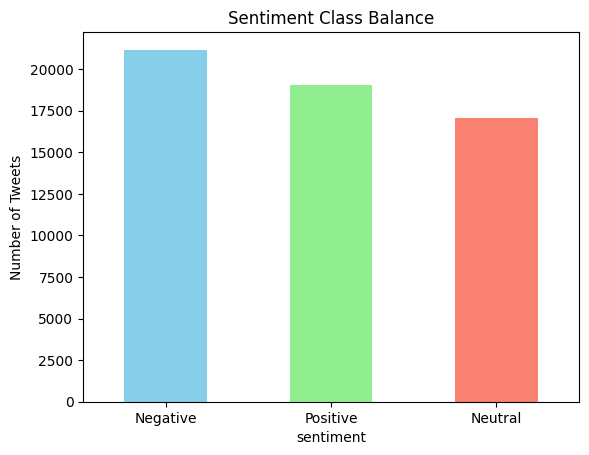

In [7]:
# Check class balance
class_counts = df['sentiment'].value_counts()
print("Class Distribution:\n", class_counts)

# Visualize class balance
class_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Sentiment Class Balance')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.show()

### 3. Vocabulary Size & Semantic Modifiers
A massive raw vocabulary can lead to a highly sparse feature matrix. We will evaluate the total unique tokens and check for specific noise (like URLs and @mentions) that might artificially inflate the vocabulary without adding sentiment value. We also check for negations, which are critical to preserve for sentiment tasks.

In [8]:
# Combine all text to analyze raw vocabulary
all_text = " ".join(df['tweet_content'].str.lower())
raw_tokens = all_text.split()
raw_vocab = set(raw_tokens)

print(f"Total words (tokens) in dataset: {len(raw_tokens)}")
print(f"Raw vocabulary size (unique tokens): {len(raw_vocab)}\n")

# Count URLs, mentions, and specific negations using regex
url_count = df['tweet_content'].str.contains(r'http\S+|www\S+', regex=True, case=False).sum()
mention_count = df['tweet_content'].str.contains(r'@\w+', regex=True).sum()
negation_pattern = r'\b(not|never)\b|\w+n\'t\b'
negation_count = df['tweet_content'].str.contains(negation_pattern, regex=True, case=False).sum()

print(f"Tweets containing URLs: {url_count}")
print(f"Tweets containing @mentions: {mention_count}")
print(f"Tweets containing negations (not, never, n't): {negation_count}")

Total words (tokens) in dataset: 1140007
Raw vocabulary size (unique tokens): 60264



C:\Users\adoni\AppData\Local\Temp\ipykernel_26052\1718656154.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  negation_count = df['tweet_content'].str.contains(negation_pattern, regex=True, case=False).sum()


Tweets containing URLs: 2120
Tweets containing @mentions: 9856
Tweets containing negations (not, never, n't): 9057


### 4. Most Frequent Terms per Class
By checking the most common words per class, we can determine if the sentiments are easily separable by raw word frequency, or if standard stop words dominate the counts. This will validate our choice of a Multinomial Naive Bayes model.

In [10]:
def get_top_n_words(corpus, n=20):
    """Splits a corpus into words and returns the top n most common."""
    all_words = " ".join(corpus).lower().split()
    return Counter(all_words).most_common(n)

# Iterate through each sentiment and print top 10 words
for sentiment in df['sentiment'].unique():
    subset = df[df['sentiment'] == sentiment]['tweet_content']
    top_words = get_top_n_words(subset, n=10)
    
    print(f"\nTop 20 words in {sentiment} tweets:")
    for word, count in top_words:
        print(f"  {word}: {count}")


Top 20 words in Positive tweets:
  the: 11320
  i: 8763
  to: 7337
  and: 6678
  a: 5719
  of: 4883
  for: 4231
  is: 4147
  this: 3849
  in: 3625

Top 20 words in Neutral tweets:
  the: 10018
  /: 7438
  to: 6813
  and: 6141
  a: 5693
  i: 5264
  of: 4670
  for: 3885
  in: 3842
  .: 3491

Top 20 words in Negative tweets:
  the: 13577
  i: 9869
  to: 8794
  and: 8431
  a: 7330
  is: 6595
  of: 5552
  @: 4619
  in: 4610
  this: 4488


## 5. Text Normalization and Saving
As identified in the EDA, URLs and @mentions appear frequently but do not carry intrinsic sentiment value. Leaving them as raw text would artificially inflate our vocabulary with sparse, one-off tokens. We will replace them with standard placeholder tags (<url> and <mention>) and save the cleaned dataset for the modeling phase

In [11]:
import re
import os

# Replace URLs and @mentions with placeholder tokens
df['tweet_content'] = df['tweet_content'].str.replace(r'http\S+|www\S+', '<url>', regex=True, case=False)
df['tweet_content'] = df['tweet_content'].str.replace(r'@\w+', '<mention>', regex=True)

#check
url_count = df['tweet_content'].str.contains(r'http\S+|www\S+', regex=True, case=False).sum()
mention_count = df['tweet_content'].str.contains(r'@\w+', regex=True).sum()

print(f"After replacement - Tweets containing URLs: {url_count}")
print(f"After replacement - Tweets containing @mentions: {mention_count}")

# Ensure the processed data directory exists
os.makedirs("../data/processed", exist_ok=True)

# Save the finalized training data
train_save_path = "../data/processed/train_cleaned.csv"
df.to_csv(train_save_path, index=False)
print(f"Saved {len(df)} cleaned rows to {train_save_path}")

After replacement - Tweets containing URLs: 0
After replacement - Tweets containing @mentions: 0
Saved 57297 cleaned rows to ../data/processed/train_cleaned.csv


## Modular Processing Function (For Validation/Test Sets)
* note that the processing code is found in src/utils.py and all the steps are the ones we did on the training which is a reusable function that applies every cleaning step we just did. 

In [14]:
import sys
sys.path.append("../src")   # adjust path if needed

from utils import load_and_clean_data

file_path = "../data/raw/twitter_validation.csv"
cleaned_validation_df = load_and_clean_data(file_path)

print(f"Cleaned validation dataset shape: {cleaned_validation_df.shape}")
print(cleaned_validation_df.head())
print(f"Class Distribution in validation set:\n{cleaned_validation_df['sentiment'].value_counts()}")

cleaned_validation_df.to_csv("../data/processed/validation_cleaned.csv", index=False)
print(f"Saved {len(cleaned_validation_df)} cleaned validation rows to ../data/processed/validation_cleaned.csv")


Cleaned validation dataset shape: (827, 2)
                                       tweet_content sentiment
1  BBC News - Amazon boss Jeff Bezos rejects clai...   Neutral
2  <mention> Why do I pay for WORD when it functi...  Negative
3  CSGO matchmaking is so full of closet hacking,...  Negative
4  Now the President is slapping Americans in the...   Neutral
5  Hi <mention> I’ve had Madeleine McCann in my c...  Negative
Class Distribution in validation set:
sentiment
Neutral     285
Positive    276
Negative    266
Name: count, dtype: int64
Saved 827 cleaned validation rows to ../data/processed/validation_cleaned.csv
